In [ ]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [13]:
especies

['Pinus',
 'Juniperus',
 'Betula',
 'Corylus',
 'Alnus',
 'Salix',
 'Ulmus',
 'Populus',
 'Acer',
 'Fraxinus',
 'Tilia',
 'Juglans',
 'Pistacia',
 'Rhamnus',
 'Buxus',
 'Sambucus',
 'Viburnum',
 'Tamarix',
 'Ephedra distachya',
 'Ephedra fragilis',
 'Ericaceae',
 'Hereda helix',
 'Ilex aquifolium',
 'Lonicera',
 'Oleaceae',
 'Myrtus',
 'Poaceae',
 'Artemisia',
 'Cichorioideae',
 'Asteroideae',
 'Cardueae',
 'Rubiaceae',
 'Centaurea',
 'Chenopodiaceae',
 'Caryophyllaceae',
 'Plantago',
 'Brassicaceae',
 'Saxifragaceae',
 'Fabaceae',
 'Genista',
 'Lotus type',
 'Trifolium type',
 'Rosaceae',
 'Ribes',
 'Boraginaceae',
 'Sedum',
 'Helianthemum',
 'Lamiaceae',
 'Urticaceae',
 'Rumex',
 'Berberidaceae',
 'Euphorbiaceae',
 'Primulaceae',
 'Scrophulariaceae',
 'Papaver',
 'Campanulaceae',
 'Convolvulaceae',
 'Liliaceae',
 'Iridaceae',
 'Crassulaceae',
 'Ranunculaceae',
 'Cistaceae',
 'Apiaceae',
 'Valerianaceae',
 'Ranunculus']

In [27]:
# Cambia esto por el nombre real del archivo
nombre_archivo = "results_w1_def_sc.pkl"

with open(nombre_archivo, "rb") as f:
    data = pickle.load(f)

# Extraer elementos
especies = data["especies"]
coef = data["matriz_coeficientes"]
sig = data["matriz_significancia"]
pval = data["matriz_pvalores"]
mean = data["matriz_medias"]
std = data["matriz_std"]

def obtener_valores(especie1, especie2):
    if especie1 not in especies or especie2 not in especies:
        print("Alguna especie no está en la lista")
        return
    
    i = especies.index(especie1)
    j = especies.index(especie2)
    
    print(f"Relación: {especie1} vs {especie2}")
    print(f"Coeficiente: {coef[i][j]}")
    print(f"Significancia: {sig[i][j]}")
    print(f"P-valor: {pval[i][j]}")
    print(f"Media: {mean[i][j]}")
    print(f"Std: {std[i][j]}")

    print(f"Relación: {especie2} vs {especie1}")
    print(f"Coeficiente: {coef[j][i]}")
    print(f"Significancia: {sig[j][i]}")
    print(f"P-valor: {pval[j][i]}")
    print(f"Media: {mean[j][i]}")
    print(f"Std: {std[j][i]}")


sp1="Pinus"
sp2="Betula"


obtener_valores(sp1, sp2)

Relación: Pinus vs Betula
Coeficiente: -0.023132397932317222
Significancia: 0.0
P-valor: 0.493
Media: -0.0002630511089577968
Std: 0.045199757793067556
Relación: Betula vs Pinus
Coeficiente: -0.7477187673009833
Significancia: 0.0
P-valor: 0.084
Media: -0.006221902493177949
Std: 0.47002222225519186


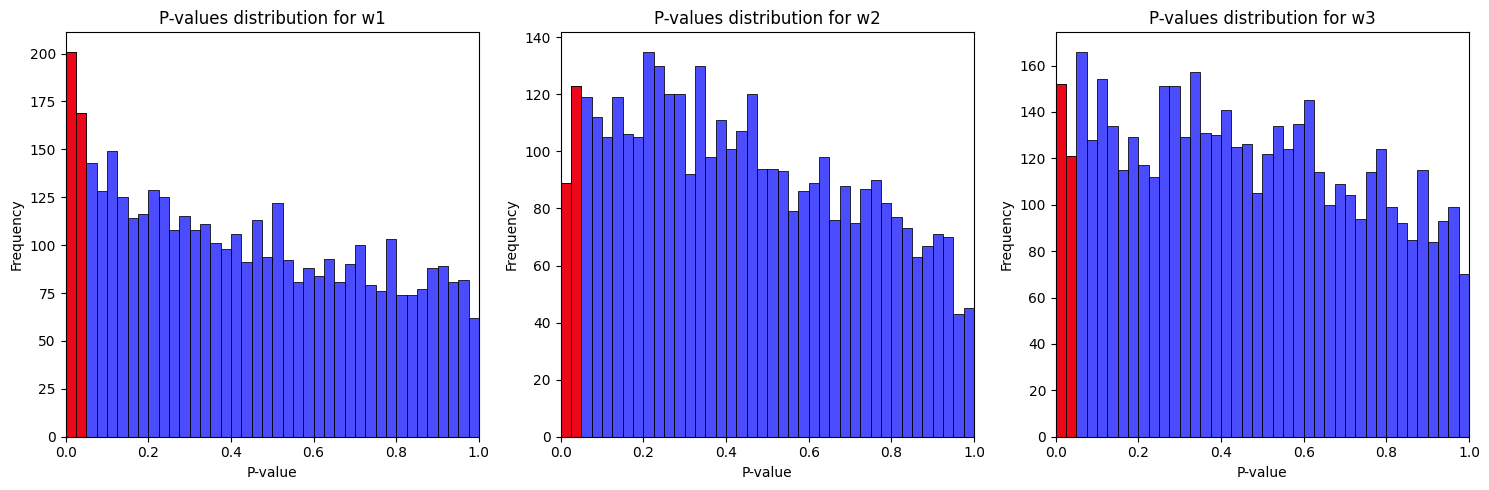

In [21]:
# plotear histograma de p_values para cada ventana temporal en una misma figura, con 3 subplots (1 por ventana temporal)
# color rojo en los p_values menores a 0.05, y azul en los mayores a 0.05
windows_names=["w1", "w2", "w3"]


fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for idx, window_name in enumerate(windows_names):
    with open(f"results_{window_name}_def_2.pkl", "rb") as f:
        data = pickle.load(f)

    p_values = np.array(data["matriz_pvalores"])
    p_values = p_values.flatten()
    p_values = p_values[~np.isnan(p_values)]

    # sns.histplot(p_values, bins=50, ax=axes[idx], )
    # sns.histplot(p_values[p_values < 0.05], bins=50, ax=axes[idx], color='red')
    sns.histplot(p_values, binwidth=0.025, ax=axes[idx], color='blue', alpha=0.7, stat='count')
    sns.histplot(p_values[p_values < 0.05], binwidth=0.025, ax=axes[idx], color='red', alpha=0.9, stat='count')
    axes[idx].set_title(f'P-values distribution for {window_name}')
    axes[idx].set_xlabel('P-value')
    axes[idx].set_ylabel('Frequency')
    axes[idx].set_xlim(0, 1)

plt.tight_layout()
plt.show()


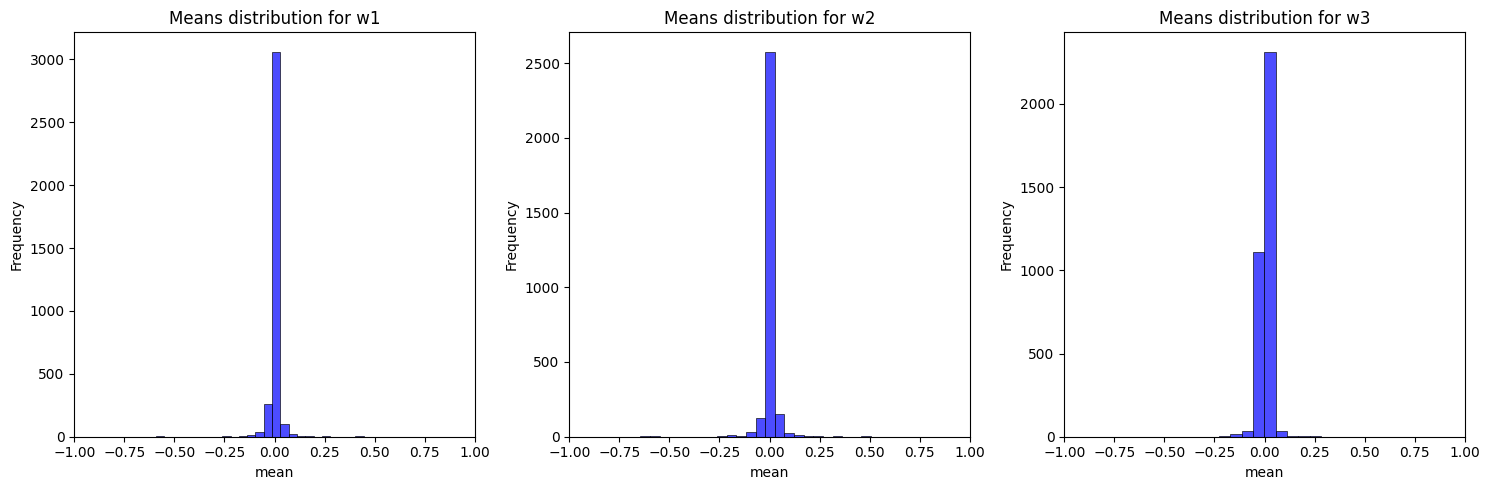

In [23]:
# plotear histograma de p_values para cada ventana temporal en una misma figura, con 3 subplots (1 por ventana temporal)
# color rojo en los p_values menores a 0.05, y azul en los mayores a 0.05
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for idx, window_name in enumerate(windows_names):
    with open(f"results_{window_name}_def_sc.pkl", "rb") as f:
        data = pickle.load(f)

    p_values = np.array(data["matriz_medias"])
    p_values = p_values.flatten()
    p_values = p_values[~np.isnan(p_values)]

    # sns.histplot(p_values, bins=50, ax=axes[idx], )
    # sns.histplot(p_values[p_values < 0.05], bins=50, ax=axes[idx], color='red')
    sns.histplot(p_values, bins=50, ax=axes[idx], color='blue', alpha=0.7, stat='count')
    #sns.histplot(p_values[p_values < 0.05], binwidth=0.025, ax=axes[idx], color='red', alpha=0.9, stat='count')
    axes[idx].set_title(f'Means distribution for {window_name}')
    axes[idx].set_xlabel('mean')
    axes[idx].set_ylabel('Frequency')
    axes[idx].set_xlim(-1, 1)

plt.tight_layout()
plt.show()


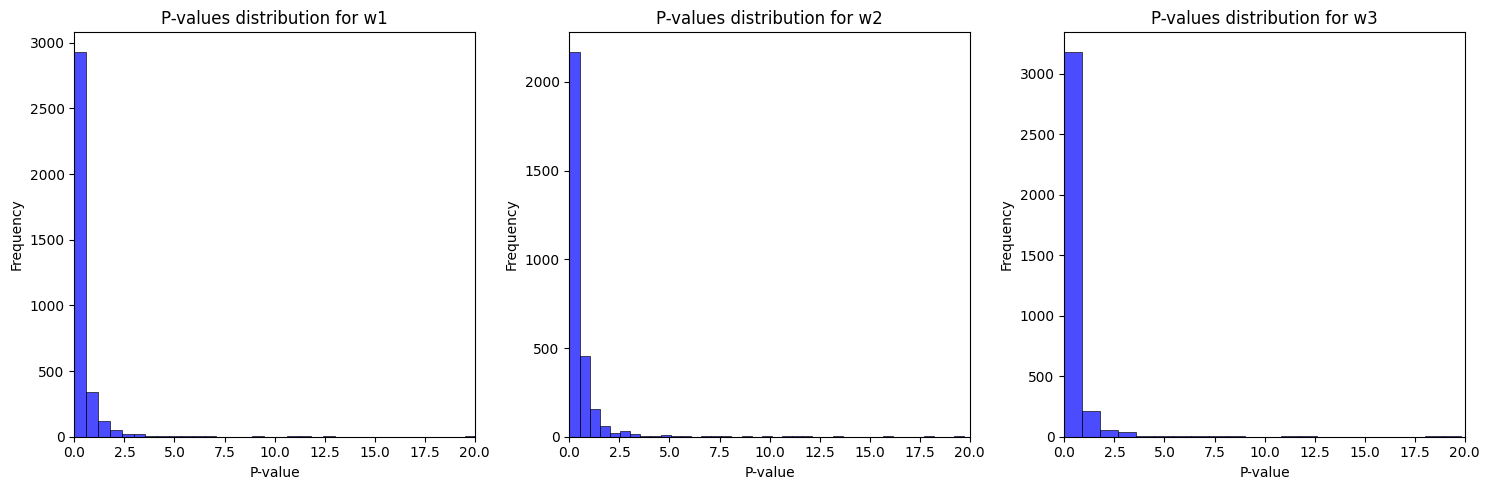

In [26]:
# plotear histograma de p_values para cada ventana temporal en una misma figura, con 3 subplots (1 por ventana temporal)
# color rojo en los p_values menores a 0.05, y azul en los mayores a 0.05
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for idx, window_name in enumerate(windows_names):
    with open(f"results_{window_name}_def_sc.pkl", "rb") as f:
        data = pickle.load(f)

    p_values = np.array(data["matriz_std"])
    p_values = p_values.flatten()
    p_values = p_values[~np.isnan(p_values)]

    # sns.histplot(p_values, bins=50, ax=axes[idx], )
    # sns.histplot(p_values[p_values < 0.05], bins=50, ax=axes[idx], color='red')
    sns.histplot(p_values, bins=50, ax=axes[idx], color='blue', alpha=0.7, stat='count')
    #sns.histplot(p_values[p_values < 0.05], binwidth=0.025, ax=axes[idx], color='red', alpha=0.9, stat='count')
    axes[idx].set_title(f'P-values distribution for {window_name}')
    axes[idx].set_xlabel('P-value')
    axes[idx].set_ylabel('Frequency')
    axes[idx].set_xlim(0, 20)

plt.tight_layout()
plt.show()


In [32]:
import numpy as np
from scipy.stats import chi2

N = 1000
ALPHA = 0.05

def intervalo_std(s, n=N, alpha=ALPHA):
    """
    Intervalo de confianza para la desviación estándar
    """
    
    chi2_inf = chi2.ppf(alpha / 2, df=n-1)
    chi2_sup = chi2.ppf(1 - alpha / 2, df=n-1)
    
    lower = np.sqrt((n-1) * s**2 / chi2_sup)
    upper = np.sqrt((n-1) * s**2 / chi2_inf)
    
    return (lower, upper)


def obtener_valores(sp1, sp2):
    if sp1 not in especies or sp2 not in especies:
        print("Alguna especie no está en la lista")
        return
    
    i = especies.index(sp1)
    j = especies.index(sp2)
    
    def analizar(i, j, label):
        m = mean[i][j]
        s = std[i][j]
        
        # intervalo media
        margen_media = 1.96 * s / np.sqrt(N)
        intervalo_media = (m - margen_media, m + margen_media)
        
        # intervalo std
        intervalo_s = intervalo_std(s)
        
        print(f"\nRelación: {label}")
        print(f"Media: {m}")
        print(f"Std: {s}")
        print(f"Intervalo media (95%): {intervalo_media}")
        print(f"Intervalo std (95%): {intervalo_s}")
    
    analizar(i, j, f"{sp1} vs {sp2}")
    analizar(j, i, f"{sp2} vs {sp1}")


sp1 = "Pinus"
sp2 = "Betula"

obtener_valores(sp1, sp2)



Relación: Pinus vs Betula
Media: -0.0002630511089577968
Std: 0.045199757793067556
Intervalo media (95%): (np.float64(-0.003064561121512964), np.float64(0.002538458903597371))
Intervalo std (95%): (np.float64(0.04330192614322503), np.float64(0.047272860838524305))

Relación: Betula vs Pinus
Media: -0.006221902493177949
Std: 0.47002222225519186
Intervalo media (95%): (np.float64(-0.03535418164829564), np.float64(0.02291037666193974))
Intervalo std (95%): (np.float64(0.4502870932837257), np.float64(0.49157995946366506))
